# Data Collection and Preprocessing for Graduation Project

## 🔗 Builds on (AIAT 111–125)

AIAT 126 is the *graduation* project: it **assembles** what you already built across the diploma, it does not re-teach it. Open what you need:

- **AIAT 115 U2 — missing values and duplicates** (this notebook does *not* re-teach it) → [`Course 05/unit2-cleaning/examples/02_missing_values_duplicates.ipynb`](../../../Course%2005/unit2-cleaning/examples/02_missing_values_duplicates.ipynb)
- **AIAT 115 U2 — scaling and encoding, the transformer you reuse here** → [`Course 05/unit2-cleaning/examples/04_feature_transformation_scaling_encoding.ipynb`](../../../Course%2005/unit2-cleaning/examples/04_feature_transformation_scaling_encoding.ipynb)
- **AIAT 114 U1 — the preprocessing-pipeline pattern** → [`Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb`](../../../Course%2004/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb)
- **AIAT 116 U3 — anonymisation: what you may legally keep about a person** → [`Course 06/unit3-privacy-security/examples/07_anonymization_pseudonymization.ipynb`](../../../Course%2006/unit3-privacy-security/examples/07_anonymization_pseudonymization.ipynb)
- **AIAT 115 U5 — only if your own file is too big for memory** → [`Course 05/unit5-scaling/examples/07_large_datasets.ipynb`](../../../Course%2005/unit5-scaling/examples/07_large_datasets.ipynb)

Record every artifact you reuse in **section 6, the Prior Work Inventory**, of [`TEMPLATES/project_proposal_template.md`](../../TEMPLATES/project_proposal_template.md). It is scored at gate 1 (criterion 1.7) and re-checked at the Unit 2 design review — it is this course's **CLO2** evidence, and the official AIAT 126 description requires it.

## 📚 Learning Objectives

By completing this notebook, you will:
- Collect and acquire datasets for graduation project
- Perform comprehensive data cleaning and preprocessing
- Implement feature engineering techniques
- Validate data quality and create train/validation/test splits
- Document data collection and preprocessing procedures

## 🔗 Where this leads

**Used later in:** Course 12 — Unit 3, lesson 02, which trains on the train/validation/test split produced here.

---

This notebook covers practical activities from **Course 12, Unit 3**:
- Collecting and acquiring datasets
- Performing data cleaning and preprocessing using Python libraries
- Implementing feature engineering techniques
- Validating data quality and preparing train/validation/test splits
- Creating data exploration notebooks with visualizations

---

## Introduction

**Data Collection and Preparation** is critical for project success. Quality data leads to quality models.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Your own project dataset**, if you have one: put it at `data/my_project_data.csv` next to this
  notebook and the pipeline below will pick it up automatically
- Otherwise the notebook falls back to a real named dataset — the 1912 Titanic passenger manifest at
  `../../../Course 04/datasets/raw/titanic.csv` — so every step runs on data with real missing values,
  real categories and a real class imbalance

**Outputs:** What you'll see when you run the cells

- A missing-value report, an imputation/encoding/scaling pipeline, three EDA figures, two
  engineered features, and a stratified 60/20/20 split — all on whichever dataset was loaded.

---

### This is not AIAT 115 again

Course 05 (AIAT 115) Unit 2 taught you **how** to clean data: missing values, duplicates,
outliers, encoding, scaling, and why each choice matters. **This notebook repeats none of that
teaching.** One thing changes, and it changes everything:

| AIAT 115 Unit 2 | AIAT 126 Unit 3 (here) |
|---|---|
| a dataset chosen *for* you, to demonstrate a technique | **the dataset you chose**, with whatever it happens to contain |
| the cleaning step **is** the lesson | the cleaning step is **infrastructure** for the system you designed in Unit 2 |
| "here is how to impute a missing value" | "here is the data plan your Unit 2 design committed to — execute it, and record every place the real data forced you to depart from it" |

**Do this before running the next cell.**

1. Put your own data at `data/my_project_data.csv`, next to this notebook. If it is not ready
   yet, the pipeline below falls back to a **real named dataset** — the 1912 Titanic passenger
   manifest from `Course 04/datasets/raw/titanic.csv` — so every step still runs on data
   somebody actually collected, with real missingness and a real class imbalance. It is a
   stand-in, not your project.
2. Open the AIAT 115 notebooks listed in **Builds on** above and reuse the steps that apply.
   You are *expected* to reuse them — that is what the Prior Work Inventory records, and
   rewriting them from scratch earns nothing.
3. Every departure from the Unit 2 data plan gets one line: **what changed and why**. That note
   is the evidence gate 3 asks for; a silent change is scored as scope drift.

---

In [1]:
# Setup: import the preprocessing toolkit — pandas/NumPy for the data itself,
# matplotlib/seaborn for the EDA plots, and scikit-learn's split/scale/encode
# utilities used by the cleaning pipeline below.
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Confirm the environment is ready before the pipeline cells run
print("✅ Libraries imported!")
print("Ready for data collection and preprocessing!")


✅ Libraries imported!
Ready for data collection and preprocessing!


## Part 1: Data Collection Strategies

Explore different data sources and collection methods.


In [2]:
# Map of data-collection strategies: for each source type, what it offers and
# what to watch out for — choosing a realistic, legally usable data source is
# the first real decision of the capstone, and licensing or ethics problems
# are far cheaper to catch now than after you have built on the data.
print("=" * 60)
print("Data Collection Strategies")
print("=" * 60)

# Four families of sources, each with concrete examples, advantages, and caveats
data_sources = {
    "Public Datasets": {
        "sources": [
            "Kaggle Datasets", "UCI Machine Learning Repository",
            "Google Dataset Search",
            "Papers with Code Datasets",
            "Hugging Face Datasets"
        ],
        "advantages": "Ready to use, often cleaned, documented",
        "considerations": "Check licensing, ensure relevance to your problem"
    },
    "APIs": {
        "sources": [
            "Twitter API (for social media analysis)",
            "Reddit API",
            "News APIs",
            "Government data APIs"
        ],
        "advantages": "Real-time data, structured format",
        "considerations": "API limits, authentication, rate limiting"
    },
    "Web Scraping": {
        "sources": [
            "BeautifulSoup + requests",
            "Scrapy framework",
            "Selenium for dynamic content"
        ],
        "advantages": "Access to large amounts of data",
        "considerations": "Legal and ethical considerations, robots.txt, ToS"
    },
    "Custom Collection": {
        "sources": [
            "Surveys",
            "Experiments",
            "Sensors/IoT devices"
        ],
        "advantages": "Tailored to your specific needs",
        "considerations": "Time-consuming, requires IRB approval for human subjects"
    }
}

# Print a compact card per strategy so the trade-offs sit side by side
for source_type, details in data_sources.items():
    print(f"\n{source_type}:")
    print(f"  Sources: {', '.join(details['sources'][:3])}...")
    print(f"  Advantages: {details['advantages']}")
    print(f"  Considerations: {details['considerations']}")

print("\n✅ Choose data sources aligned with your project goals and ethical guidelines!")


Data Collection Strategies

Public Datasets:
  Sources: Kaggle Datasets, UCI Machine Learning Repository, Google Dataset Search...
  Advantages: Ready to use, often cleaned, documented
  Considerations: Check licensing, ensure relevance to your problem

APIs:
  Sources: Twitter API (for social media analysis), Reddit API, News APIs...
  Advantages: Real-time data, structured format
  Considerations: API limits, authentication, rate limiting

Web Scraping:
  Sources: BeautifulSoup + requests, Scrapy framework, Selenium for dynamic content...
  Advantages: Access to large amounts of data
  Considerations: Legal and ethical considerations, robots.txt, ToS

Custom Collection:
  Sources: Surveys, Experiments, Sensors/IoT devices...
  Advantages: Tailored to your specific needs
  Considerations: Time-consuming, requires IRB approval for human subjects

✅ Choose data sources aligned with your project goals and ethical guidelines!


## Part 2: Data Cleaning and Preprocessing Pipeline

Comprehensive data cleaning workflow — run on **your** dataset.

The next cell looks for your project data at `data/my_project_data.csv`. If it is not there
yet, it loads a real fallback dataset (the 1912 Titanic passenger manifest) so that every
step below still runs on data somebody actually collected — with the missing values, odd
categories and class imbalance that come with it.

**When you switch to your own file, change the four names in the `EDIT THIS BLOCK` section**
so the pipeline knows which columns are numeric, which is categorical, and which is the target.

In [3]:
# Load the project dataset (yours if present, a real named fallback otherwise) and run the
# full cleaning pipeline on it: inspect -> impute -> encode -> scale.
# WHY a real fallback rather than random numbers: an imputation step only teaches you
# anything if the gaps are gaps somebody actually left in a record.
PROJECT_DATA = Path("data/my_project_data.csv")      # <- your own dataset goes here
FALLBACK_DATA = Path("../../../Course 04/datasets/raw/titanic.csv")

if PROJECT_DATA.exists():
    raw_data = pd.read_csv(PROJECT_DATA)
    data_source = f"YOUR project dataset ({PROJECT_DATA})"
else:
    raw_data = pd.read_csv(FALLBACK_DATA)
    data_source = f"fallback: real Titanic passenger manifest ({FALLBACK_DATA.name}, 1912)"
    print(f"ℹ️  No file at {PROJECT_DATA} — using the real fallback dataset instead.")
    print("   Drop your own CSV there and re-run: everything below adapts.\n")

# ---------------------- EDIT THIS BLOCK for your own data ----------------------
NUMERIC_FEATURES = ["Age", "Fare"]        # continuous columns
CATEGORICAL_FEATURE = "Embarked"          # one categorical column to encode
TARGET = "Survived"                       # the column you want to predict
# -------------------------------------------------------------------------------

needed = NUMERIC_FEATURES + [CATEGORICAL_FEATURE, TARGET]
missing_cols = [c for c in needed if c not in raw_data.columns]
assert not missing_cols, (
    f"Columns {missing_cols} are not in {data_source}. "
    "Update the EDIT THIS BLOCK section above with your own column names."
)

sample_data = raw_data[needed].copy()

print("=" * 60)
print("Data Cleaning Pipeline")
print("=" * 60)
print(f"Source: {data_source}")

print("\n1. Initial Data Inspection:")
print(f"   Shape: {sample_data.shape}")
print(f"   Missing values:\n{sample_data.isnull().sum()}")
print(f"   Target balance: {sample_data[TARGET].value_counts().to_dict()}")

# Handle missing values
print("\n2. Handling Missing Values:")
# Option 1: Drop rows with missing values
data_dropped = sample_data.dropna()
print(f"   After dropping: {data_dropped.shape} "
      f"({len(sample_data) - len(data_dropped)} rows lost — is that acceptable?)")

# Option 2: Fill missing values (median for numeric, mode for categorical)
# WHY median rather than mean: it survives the outliers real data is full of.
data_filled = sample_data.copy()
for col in NUMERIC_FEATURES:
    data_filled[col] = data_filled[col].fillna(data_filled[col].median())
data_filled[CATEGORICAL_FEATURE] = data_filled[CATEGORICAL_FEATURE].fillna(
    data_filled[CATEGORICAL_FEATURE].mode()[0])
print(f"   After filling: Missing values = {data_filled.isnull().sum().sum()}")
print("   Note what imputation did: it invented plausible values. Say so in your report.")

# Handle categorical variables
print("\n3. Encoding Categorical Variables:")
le = LabelEncoder()
data_encoded = data_filled.copy()
data_encoded[f"{CATEGORICAL_FEATURE}_encoded"] = le.fit_transform(
    data_encoded[CATEGORICAL_FEATURE])
print(f"   Original categories: {data_filled[CATEGORICAL_FEATURE].unique().tolist()}")
print(f"   Encoded values: {sorted(data_encoded[f'{CATEGORICAL_FEATURE}_encoded'].unique().tolist())}")
print("   Careful: LabelEncoder imposes an ORDER. Use one-hot instead when there isn't one.")

# Feature scaling
print("\n4. Feature Scaling:")
scaler = StandardScaler()
data_scaled = data_encoded.copy()
data_scaled[NUMERIC_FEATURES] = scaler.fit_transform(data_scaled[NUMERIC_FEATURES])
print(f"   Features scaled: {NUMERIC_FEATURES}")
print(f"   Mean after scaling: {data_scaled[NUMERIC_FEATURES].mean().round(4).tolist()}")
print(f"   Std after scaling: {data_scaled[NUMERIC_FEATURES].std().round(4).tolist()}")

print("\n✅ Data cleaning pipeline complete!")

ℹ️  No file at data/my_project_data.csv — using the real fallback dataset instead.
   Drop your own CSV there and re-run: everything below adapts.

Data Cleaning Pipeline
Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)

1. Initial Data Inspection:
   Shape: (891, 4)
   Missing values:
Age         177
Fare          0
Embarked      2
Survived      0
dtype: int64
   Target balance: {0: 549, 1: 342}

2. Handling Missing Values:
   After dropping: (712, 4) (179 rows lost — is that acceptable?)
   After filling: Missing values = 0
   Note what imputation did: it invented plausible values. Say so in your report.

3. Encoding Categorical Variables:
   Original categories: ['S', 'C', 'Q']
   Encoded values: [0, 1, 2]
   Careful: LabelEncoder imposes an ORDER. Use one-hot instead when there isn't one.

4. Feature Scaling:
   Features scaled: ['Age', 'Fare']
   Mean after scaling: [0.0, 0.0]
   Std after scaling: [1.0006, 1.0006]

✅ Data cleaning pipeline complete!


### Exploratory Data Analysis (EDA) Visualizations

Before modeling, *look* at the data. Quick plots catch problems that summary
numbers hide: skewed distributions, dominant categories, and imputation
artifacts. Build plots like these for your own project dataset.

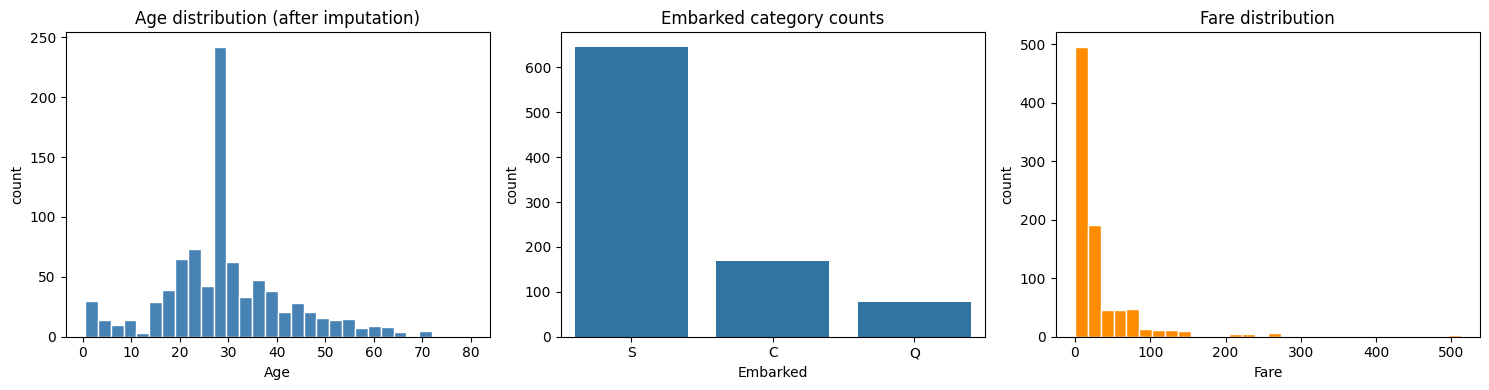

👀 Look for: the spike in 'Age' where imputation piled every missing row onto
   the median, the long right tail of 'Fare', and any category that dominates
   'Embarked'. All three change what your model can learn.
✅ EDA figures rendered — always look at distributions before you model!


In [4]:
# EDA visualizations: plot the data BEFORE modeling so surprises (skew,
# category imbalance, imputation artifacts) are caught early, not after training.
num_a, num_b = NUMERIC_FEATURES[0], NUMERIC_FEATURES[1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of the first numeric feature: shows its shape (outliers, skew)
axes[0].hist(data_filled[num_a], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'{num_a} distribution (after imputation)')
axes[0].set_xlabel(num_a)
axes[0].set_ylabel('count')

# Bar chart of the categorical column: reveals rare or dominant categories
sns.countplot(x=CATEGORICAL_FEATURE, data=data_filled, ax=axes[1])
axes[1].set_title(f'{CATEGORICAL_FEATURE} category counts')

# Histogram of the second numeric feature: real money/measure columns are usually skewed
axes[2].hist(data_filled[num_b], bins=30, color='darkorange', edgecolor='white')
axes[2].set_title(f'{num_b} distribution')
axes[2].set_xlabel(num_b)
axes[2].set_ylabel('count')

# Render all three panels side by side
plt.tight_layout()
plt.show()

print(f"👀 Look for: the spike in '{num_a}' where imputation piled every missing row onto")
print(f"   the median, the long right tail of '{num_b}', and any category that dominates")
print(f"   '{CATEGORICAL_FEATURE}'. All three change what your model can learn.")
print('✅ EDA figures rendered — always look at distributions before you model!')

### Feature Engineering

Cleaning makes data *usable*; feature engineering makes it *informative*.
Below we build two new features from the existing columns — an interaction
term and a quartile bin — the same techniques you can apply to your own
project data.

In [5]:
# Feature engineering: create NEW columns from existing ones so the model
# gets signals the raw features do not expose directly.
data_features = data_scaled.copy()

# Interaction feature: the product of the two numeric features
interaction_col = f"{num_a}_x_{num_b}"
data_features[interaction_col] = data_features[num_a] * data_features[num_b]

# Binned feature: which quartile of the first numeric feature each row falls in.
# duplicates='drop' is needed on real data, where ties (e.g. many imputed medians)
# can make two quartile edges identical.
bin_col = f"{num_a}_bin"
data_features[bin_col] = pd.qcut(data_features[num_a], q=4, labels=False, duplicates='drop')

# Show the engineered columns next to the source columns they came from
print('=' * 60)
print('Engineered Features')
print('=' * 60)
print(data_features[[num_a, num_b, interaction_col, bin_col]].head())
print(f"\nQuartile bins actually produced: {sorted(data_features[bin_col].unique().tolist())}")
print(f"Columns now available: {list(data_features.columns)}")
print('\n✅ Feature engineering complete — 2 new features created!')

Engineered Features
        Age      Fare  Age_x_Fare  Age_bin
0 -0.565736 -0.502445    0.284252        0
1  0.663861  0.786845    0.522356        3
2 -0.258337 -0.488854    0.126289        1
3  0.433312  0.420730    0.182307        2
4  0.433312 -0.486337   -0.210736        2

Quartile bins actually produced: [0, 1, 2, 3]
Columns now available: ['Age', 'Fare', 'Embarked', 'Survived', 'Embarked_encoded', 'Age_x_Fare', 'Age_bin']

✅ Feature engineering complete — 2 new features created!


## Part 3: Train/Validation/Test Split

Proper data splitting for model development and evaluation.


In [6]:
# Split the prepared data into train/validation/test sets so tuning and the
# final evaluation each get data the model has never seen.
# Features: the cleaned columns plus the two engineered ones from the previous cell
feature_cols = NUMERIC_FEATURES + [f"{CATEGORICAL_FEATURE}_encoded", interaction_col, bin_col]
X = data_features[feature_cols]
y = data_features[TARGET]

# Split: 60% train, 20% validation, 20% test (stratified keeps class balance)
# First carve off the test set, then split the rest into train and validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Report the sizes so the 60/20/20 ratio is visible
print("=" * 60)
print("Data Splitting Strategy")
print("=" * 60)
print(f"Source: {data_source}")
print(f"Features used: {feature_cols}")
print(f"Total samples: {len(X)}")
print(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\n✅ Data split complete!")
print("📝 Use validation set for hyperparameter tuning")
print("📝 Use test set ONLY for final evaluation")

Data Splitting Strategy
Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)
Features used: ['Age', 'Fare', 'Embarked_encoded', 'Age_x_Fare', 'Age_bin']
Total samples: 891
Training set: 534 (59.9%)
Validation set: 178 (20.0%)
Test set: 179 (20.1%)

✅ Data split complete!
📝 Use validation set for hyperparameter tuning
📝 Use test set ONLY for final evaluation


## Summary

### Key Steps in Data Collection & Preparation:
1. **Data Collection**: Identify and acquire relevant datasets
2. **Data Inspection**: Understand data structure, types, distributions
3. **Data Cleaning**: Handle missing values, outliers, inconsistencies
4. **Feature Engineering**: Create meaningful features from raw data
5. **Data Splitting**: Train/Validation/Test sets (60/20/20 or 70/15/15)
6. **Documentation**: Document all preprocessing steps for reproducibility

### Best Practices:
- Always check data quality before modeling
- Document all preprocessing steps
- Save cleaned datasets for reproducibility
- Use stratified splitting for imbalanced data
- Validate data representativeness

### Running this on your own project data
1. Save your dataset as `data/my_project_data.csv` next to this notebook.
2. Edit the four names in the `EDIT THIS BLOCK` section (two numeric columns, one categorical column, the target).
3. Re-run the notebook top to bottom. Every print, plot and split adapts to your columns.
4. Read the missing-value report *before* you touch a model, and write down in your project report which imputation choices you made and why.

**Reference:** Course 12, Unit 3: "Implementation and Development of the Project Idea" — the data pipeline above (collection strategy, cleaning, EDA visualizations, feature engineering, splitting) runs on your own dataset when you supply one, and otherwise on the real Titanic manifest, so nothing here depends on invented numbers.


## 📚 References

1. Wickham, H. (2014). *Tidy Data*. Journal of Statistical Software, 59(10), 1–23. <https://doi.org/10.18637/jss.v059.i10>
2. Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
3. Sambasivan, N., Kapania, S., Highfill, H., et al. (2021). *"Everyone wants to do the model work, not the data work": Data Cascades in High-Stakes AI*. CHI 2021. <https://doi.org/10.1145/3411764.3445518>